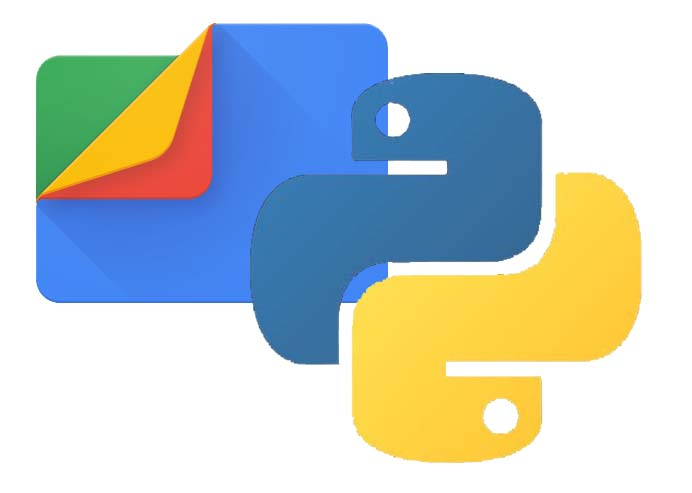

## TRABAJANDO CON FICHEROS

Los desarrolladores de aplicaciones siempre están trabajando con archivos. Los crean cada vez que escriben un nuevo script o aplicación. Escriben informes en Microsoft Word, guardan correos electrónicos o descargan libros o música. **Los archivos están en todas partes.** Tu navegador web descarga muchos archivos pequeños para que nuestra experiencia de navegación sea más rápida.

Cuando escribes programas, tienes que interactuar con archivos preexistentes o escribir archivos tú mismo.
Python proporciona una buena función integrada llamada open() que puede ayudarnos con estas tareas.

**En este Notebook aprenderemos cómo:**
* Abrir archivos
* Leer archivos
* Escribir archivos
* Agregar datos a archivos existentes.
* Copiar directorios
* Leer un rango de líneas de un fichero
* Reemplazar texto en un fichero
* Acceso Aleatorio en fichero.

¡Empecemos!

___
### <font color='green'>1. Función Open</font>


Puedes abrir un archivo para leerlo, escribirlo o agregar información al final. Para abrir un archivo, puedes usar la función integrada **open().**

Los argumentos de la función son:

**open(file, mode='r', buffering=-1, encoding=None, errors=None, newline=None, closefd=True, opener=None)**

Cuando abre un archivo, **debe pasar un nombre de archivo o una ruta de archivo.** El valor **predeterminado** al abrir un archivo es abrirlo en <font color='green'>**modo de solo lectura,**</font> que es lo que significa la 'r'.

**La siguiente tabla repasa los otros modos que se pueden usar al abrir un archivo:**

* <font color='green'>r -> abre un archivo solo para lectura.</font> El puntero al archivo esta localizado al comienzo del archivo. Este es el modo predeterminado de la función.


* <font color='green'>rb -> abre un archivo solo para lectura en formato binario.</font> El puntero al archivo esta localizado al comienzo del archivo. Este es el modo predeterminado de la función.

* <font color='green'>r+ -> abre un archivo para escritura y lectura.</font> El puntero del archivo está localizado al comienzo del archivo.


* <font color='green'>w -> abre un archivo solo para escritura.</font> Sobreescribe el archivo si este ya existe. Si el archivo no existe, crea un nuevo archivo para escritura.


* <font color='green'>wb -> abre un archivo solo para escritura en formato binario.</font> Sobreescribe el archivo si este ya existe. Si el archivo no existe, crea un nuevo archivo para escritura.


* <font color='green'>w+ -> abre un archivo para escritura y lectura.</font> Sobreescribe el archivo si este ya existe. Si el archivo no existe, crea un nuevo archivo para escritura.


* <font color='green'>a -> abre un archivo para escritura.</font> El puntero del archivo esta al final del archivo si este existe. Es decir, si el archivo existe añade los datos al final del mismo. Si el archivo no existe, crea un nuevo archivo para escritura.

Hay dos métodos principales que se utilizan para abrir un archivo. Puedes hacer algo como esto:

In [19]:
manejador_fichero = open('example2.txt')#fichero correcto example.txt
# hacer algo con el fichero
manejador_fichero.close()

Aquí abrimos el archivo y lo cerramos. 

**Pero, ¿qué sucede si se produce una excepción al intentar abrir el archivo?** 

* Por ejemplo, supongamos que intentas abrir un archivo que no existe. 

* O abres un archivo, pero no puedes escribir en él. Estas cosas suceden y pueden hacer que un identificador de archivo se deje abierto y no se cierre correctamente.

**Una solución es usar try/except:**

In [21]:
try:
    manejador_fichero = open('examp.txt')
    
except FileNotFoundError as fnf:     
    # ignora el error, imprimimos un warning o el log de la excepción
    print("Error al intentar abrir el fichero: ", fnf)    
else:    
    manejador_fichero.close()    

    

Error al intentar abrir el fichero:  [Errno 2] No such file or directory: 'examp.txt'


**Sin embargo, la mejor manera de abrir un archivo en Python es usar la instrucción especial with de Python.** 

* La declaración **with** activa lo que se conoce como un administrador de contexto. Los administradores de contexto se encargan de abrir y cerrar el fichero. **No es necesario hacer el close**

En este ejemplo, desea abrir un archivo, hacer algo y luego cerrar el archivo. Puedes hacerlo de la siguiente forma:

In [ ]:
with open('example.txt', encoding='utf-8') as manejador_fichero:
    # hacer algo con el manejador del fichero
    data = manejador_fichero.read()

print(data)    

a
aba
ába
abaá
ababilla
ababílla
ababillaba
ababillabais
ababillábamos


Lo que hace es abrir el archivo y asignar el objeto de archivo al **manejador_fichero.** Entonces, cualquier código que esté sangrado para estar dentro de la declaración with se considera parte del contexto. Eso es donde interactuaría con el controlador de archivos, ya sea leyendo o escribiendo en el archivo. Luego, cuando salga de la declaración with, cerrará automáticamente el archivo.

**Ahora que sabes cómo abrir un archivo, avancemos y aprendamos a leer un archivo con Python.**

---
### <font color='green'>2. Leyendo Ficheros</font>

Leer archivos con el lenguaje de programación Python es bastante sencillo. De hecho, cuando abres un archivo y no estableces el argumento de modo, el valor predeterminado es abrir el archivo en modo de **"solo lectura".**

---
### 2.1 Utilizando el Manejador de Fichero

* Este código abrirá el archivo de texto y luego recorrerá cada línea del archivo y lo imprimirá. **Sí, el manejador_fichero se puede iterar usando el bucle for de Python,** lo cual es muy útil. 


* De hecho, esto es en realidad, uno de los **métodos recomendados para leer un archivo mientras lo lee en fragmentos para que no se quede sin memoria.**

In [23]:
with open('example.txt',encoding='UTF-8') as manejador_fichero:
    for linea in manejador_fichero:
        print(linea)

a

aba

ába

abaá

ababilla

ababílla

ababillaba

ababillabais

ababillábamos


---
### 2.2 Leer todas las lineas e ir mostrandolas

El siguiente método, simplemente **lee el archivo completo en la memoria.** 

Dependiendo de la cantidad de RAM que tengamos, es posible que nos quedemos sin memoria. Por eso se **recomienda el primer método.**

In [24]:
with open('example.txt',encoding='UTF-8') as manejador_fichero:
    lineas = manejador_fichero.readlines()
    for linea in lineas:
        print(linea)

a

aba

ába

abaá

ababilla

ababílla

ababillaba

ababillabais

ababillábamos


---
### 2.3 Leyendo Ficheros Pequeños

Sin embargo, si sabes que el archivo es bastante pequeño, hay otra forma de leer el archivo completo en la memoria.

El método read() leerá el archivo completo en la memoria y lo asignará a su variable.

In [25]:
with open('example.txt', encoding='UTF-8') as manejador_fichero:
    contenido_fichero = manejador_fichero.read()

print(contenido_fichero)    

a
aba
ába
abaá
ababilla
ababílla
ababillaba
ababillabais
ababillábamos


---
### <font color='green'>3. Leyendo Ficheros Binarios</font>

A veces necesitaremos leer un archivo binario. Python también puede hacer eso al **combinar el modo r con b:**

In [ ]:
with open('example.pdf', 'rb') as manejador_fichero:
    contenido = manejador_fichero.read()

---
### <font color='green'>4. Escribiendo Ficheros</font>

* Escribir un archivo nuevo en Python usa prácticamente la misma sintaxis que leer. Pero en lugar de configurar el modo en r, **lo configura en w para el modo de escritura.** 


* Si necesita **escribir en modo binario,** entonces abriría el archivo en modo **wb.**


<font color='green'>**ADVERTENCIA:**</font>

* **Al usar los modos w y wb, si el archivo ya existe, terminará sobrescribiéndolo.** Python no le advierte de ninguna manera. Python proporciona una forma de verificar la existencia de un archivo mediante el uso del módulo os a través de **os.path.exists().**

Escribamos una sola línea de texto en un archivo:

In [26]:
with open('example1.txt', 'w') as manejador:
    manejador.write('Esto es una prueba')

In [27]:
with open('example1.txt', 'w') as manejador:
    manejador.write('Ahora voy a añadir otra linea, qué pasa con la anterior?')#sí, nos la hemos cepillado :(

In [28]:
import os

if os.path.exists('example1.txt'):
    respuesta = input("El archivo example1.txt ya existe. Desea seguir? S/N")
if respuesta == 'S':
    with open('example1.txt', 'w') as manejador:
        manejador.write('Añadimos otra linea sabiendo que vamos a borrar el contenido.')
else:
    print("Salimos sin hacer nada.")

El archivo example1.txt ya existe. Desea seguir? S/N S


Si necesitamos escribir varias líneas a la vez, puedes usar el método **writelines(), que acepta una secuencia de cadenas.**

**Podríamos usar una lista de cadenas y pasarlas a writelines(), por ejemplo.**

In [29]:
lineas = ['Esto es una cadena1 \n','Cadena 2. En un lugar de la mancha de cuyo nombre...\n','Cadena3. No quiero acordarme']
with open('example1.txt', 'w') as manejador:
        manejador.writelines(lineas)

---
### <font color='green'>5. Posicionandonos dentro de un archivo</font>

El controlador de archivos también proporciona otro método que vale la pena mencionar. 

Ese método es **seek () con él puedes decirle a Python en qué lugar el archivo desde el que empezar a leer.**

**El método seek() acepta dos argumentos:**

* **offset** - Un número de bytes desde donde posicionarse
* **whence** - El punto de referencia.

El punto de referencia lo podemos poner en uno de estos 3 valores.

* **0** - El comienzo del archivo (predeterminado)
* **1** - La posición actual del archivo
* **2** - El final del archivo

Usemos el archivo que escribimos anteriormente como ejemplo:

In [30]:
with open('example1.txt', 'r') as manejador_fichero:
    manejador_fichero.seek(4)
    trozo = manejador_fichero.read()
    print(trozo)

 es una cadena1 
Cadena 2. En un lugar de la mancha de cuyo nombre...
Cadena3. No quiero acordarme


El seek es más habitual en archivos binarios.

In [ ]:
#vamos a crear un fichero binario
with open('Example3', 'wb') as manejador_fichero:
    manejador_fichero.write(b'Hola mundo!!')
    print('Archivo creado')


Archivo creado


In [ ]:
#leemos a partir del 4 byte.
with open('Example3', 'rb') as manejador_fichero:
    manejador_fichero.seek(4,1)
    trozo = manejador_fichero.read()
    print(trozo)


b' mundo!!'


Aquí se abre el archivo "Example3" en modo binario "rb" (lectura binaria) y luego se utiliza el método seek() para mover el cursor al byte 4 del archivo. Luego, se utiliza el método read() para leer desde allí hasta el final del archivo, y se imprime el resultado (print(trozo)).

Si quieres leer un numero determinado de bytes se puede especificar el argumento al metodo read()

In [ ]:
with open('Example3', 'rb') as manejador_fichero:
    manejador_fichero.seek(4)
    trozo = manejador_fichero.read(10)
    print(trozo)


b' mundo!!'


---
### <font color='green'>6. Añadiendo Datos a Ficheros Existentes</font>

También podemos agregar datos a un archivo preexistente usando el modo **a**, que es el modo de "appendizar" datos al final del fichero.

**Veamos un ejemplo:**

In [31]:
with open('example1.txt', 'a') as manejador:
    manejador.write('Aquí vamos a poner más texto')

### Nota:

* Si el archivo existe, esto **agregará una nueva cadena al final del archivo.** 

* Si el archivo no existe, Python **creará el archivo y le agregará estos datos.**

---
### <font color='green'>7. Capturando Excepciones de Ficheros</font>

* Cuando trabajamos con archivos, a veces encontraremos errores. Por ejemplo, es posible que no tenga los permisos adecuados para crear o editar el archivo. En ese caso, Python generará un OSError.


* Hay otros errores que ocurren ocasionalmente, pero ese es el más común cuando se trabaja con archivos.


* **Podemos usar las funciones de manejo de excepciones de Python para mantener nuestro programa funcionando:**

In [ ]:
try:
    with open('example2.txt') as manejador:
        for linea in manejador:
            print(linea)
except OSError:
    print('Ha ocurrido un error')

---
### <font color='green'>8. Comprobar si Existe un Fichero o Directorio</font>

* **Usando el módulo os**

* **Usando el módulo pathlib**

In [ ]:
import os
os.path.isfile('/path/to/some/file.txt')

In [32]:
import pathlib
path = pathlib.Path('/path/to/some/file.txt')
if path.is_file():
    print("El fichero existe")
else:
    print("El fichero no existe")

El fichero no existe


Para verificar si una ruta determinada existe o no podemos verificar explícitamente la ruta:

In [33]:
import os
path = "/home/myFiles/directory1"
if os.path.exists(path):
    print("Existe")
else:
    print("No Existe")

No Existe


---
### <font color='green'>9. Acceso Aleatorio a Fichero (Random Access File) Usando mmap</font>

El uso del módulo **mmap permite al usuario acceder aleatoriamente a ubicaciones en un archivo** mapeando el archivo en la memoria. 

### Nota: 

**Los ficheros tienen que ser binarios para hacer accesos aleatorios**

In [34]:
import mmap
with open("hello.txt", "wb") as f:
    f.write(b"Hello Python!\n")#la b fuerza a que se guarde en binario

In [35]:
with open("hello.txt", "r+b") as f:
    # mapear en memoria el archivo, tamaño 0 significa archivo completo
    mm = mmap.mmap(f.fileno(), 0)
    # leer contenido a través de métodos de archivo estándar
    print(mm.readline())  # prints b"Hello Python!\n"
    # leer contenido a través de la notación slicing
    print(mm[:5])  # prints b"Hello"
    # actualizar contenido usando la notaciónslice
    # tener en cuenta que el contenido nuevo debe tener el mismo tamaño
    mm[6:] = b" world!\n"
    # nos posicionamos de nuevo al inicio del fichero
    mm.seek(0)
    print(mm.readline())  # prints b"Hello  world!\n"
    # cerramos el mmap
    mm.close()

b'Hello Python!\n'
b'Hello'
b'Hello  world!\n'


---
### <font color='green'>10. Reemplazando Texto en un Fichero</font>

In [36]:
import fileinput
#diccionario con los reemplazos
reemplazos = {'mancha': 'EXTREMADURA',
                'No': 'SI'}

with fileinput.input('example2.txt') as f:
    for clave in reemplazos:
        valor = reemplazos[clave]
        linea = f.readline()
        linea = linea.replace(clave, valor)
        print(linea, end='')

En un lugar de la EXTREMADURA de cuyo nombre
SI quiero acordarme


---
### <font color='green'>11. Comprobar si un Fichero Está Vacio</font>

In [37]:
import os
path_to_file = 'example1.txt'
os.stat(path_to_file).st_size == 0

False

In [38]:
import os
os.path.getsize(path_to_file) > 0

True

Sin embargo, ambos generarán una excepción si el archivo no existe. Para evitar tener que detectar un error de este tipo, hacemos lo siguiente:

In [ ]:
import os
def es_fichero_vacio(fpath:str)->bool:
    '''
    Función que nos dice si un fichero es vacio o no
    
    Paramters:
    ---------
    fpath:str
        Ruta del fichero
    
    Returns:
    -------
    True si el archivo es vacio y False en caso contrario
    '''
    
    return os.path.isfile(fpath) and os.path.getsize(fpath) > 0

---
### <font color='green'>12. Leer fichero entre un rango de líneas</font>

Supongamos que deseamos iterar solo entre algunas líneas específicas de un archivo. 

**Podemos usar itertools para eso.**

In [39]:
import itertools

with open('diccionario_castellano.txt', 'r', encoding='UTF-8') as f:
    for linea in itertools.islice(f, 12, 30):#leemos las lineas con indice 12-30
        print(linea)
        
    print("Linea adicional:")



ababilláis

ababillamos

ababillan

ababillándo

ababillara

ababillará

ababillarais

ababilláramos

ababillaran

ababillarán

ababillaras

ababillarás

ababillare

ababillaré

ababillareis

ababillaréis

ababillaremos

ababilláremos

Linea adicional:


---
### <font color='green'>13. Copiar Árbol de Directorio </font>

Podemos copiar un árbol de directorios con la libreria shutil.

El directorio de destino **no debe existir todavía.**

In [14]:
import shutil
#ojo, la barra debe ser la del 7 (/)
source='Z:/1'
destination='Z:/copias'
shutil.copytree(source, destination)

'Z:/copias'

---
### <font color='green'>14. Copiar Contenido de un Fichero a Fichero Diferente</font>

In [ ]:
input_file =  'cop1.txt'
output_file = 'cop2.txt'
with open(input_file, 'r') as in_file, open(output_file, 'a') as out_file:
    for linea in in_file:
        out_file.write(linea)

* **Usando el módulo shutil**

In [ ]:
import shutil
shutil.copyfile(input_file, output_file)

### <font color='green'>15. Lectura de ficheros de la Web</font>

Para la lectura de ficheros de la web utilizamos el método `urlopen` de la clase `request` de la librería `urllib.`

Podemos hacerlo de dos formas:
1. Invocando directamente al método urlopen(url)
2. Combinando urlopen con with.

In [42]:
from urllib import request
from urllib.error import URLError
try:
    url = 'https://www.gutenberg.org/cache/epub/1619/pg1619.txt'
    f = request.urlopen(url)    
except URLError:
    print('¡La url ' + url + ' no existe!')
else:
    #contenido = f.readlines()
    #print(contenido[235:350])
    
    #Este ejemplo elimina las nuevas líneas finales y los retornos de carro antes de imprimir la salida. 
    for linea in f:
        print(linea.decode('utf-8').rstrip())
    

The Project Gutenberg eBook of La Celestina

This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

*** This is a COPYRIGHTED Project Gutenberg eBook. Details Below. ***
***     Please follow the copyright guidelines in this file.      ***


Title: La Celestina

Author: Fernando de Rojas

Release date: January 1, 1999 [eBook #1619]
                Most recently updated: April 3, 2015

Language: Spanish



*** START OF THE PROJECT GUTENBERG EBOOK LA CELESTINA ***
**This is a COPYRIGHTED Project Gutenberg Etext, Details Below**
The Project Gutenberg Etext of La Celestina by Fernando de Rojas

Copyright 199

In [43]:
from urllib import request
from urllib.error import URLError
try:
    url = 'https://www.gutenberg.org/cache/epub/1619/pg1619.txt'
    with request.urlopen(url) as f:
        contenido = f.readlines()
except URLError:
    print('¡La url ' + url + ' no existe!')
else:
    #print(contenido[235:300])
    
    #Este ejemplo elimina las nuevas líneas finales y los retornos de carro antes de imprimir la salida. 
    for linea in f:
        print(linea.decode('utf-8').rstrip())
        

[b'indirectly from any of the following that you do or cause:\r\n', b'[1] distribution of this etext, [2] alteration, modification,\r\n', b'or addition to the etext, or [3] any Defect.\r\n', b'\r\n', b"WHAT IF YOU *WANT* TO SEND MONEY EVEN IF YOU DON'T HAVE TO?\r\n", b'Project Gutenberg is dedicated to increasing the number of\r\n', b'public domain and licensed works that can be freely distributed\r\n', b'in machine readable form.  The Project gratefully accepts\r\n', b'contributions in money, time, scanning machines, OCR software,\r\n', b'public domain etexts, royalty free copyright licenses,\r\n', b'and whatever else you can think of.  Money should be paid to\r\n', b'"Project Gutenberg Association/Carnegie-Mellon University".\r\n', b'\r\n', b'*SMALL PRINT! Ver.04.29.93 FOR COPYRIGHT PROTECTED ETEXTS*END*\r\n', b'\r\n', b'\r\n', b'\r\n', b'\r\n', b'\r\n', b'**This is a COPYRIGHTED Project Gutenberg Etext, Details Below**\r\n', b'The Project Gutenberg Etext of La Celestina by Fernando 

---
## <font color='green'>Resumen</font>

Ahora conocemos los conceptos básicos para trabajar con archivos en Python. 

* En este Notebook aprendimos a abrir archivos. 

* Leer y escribir archivos. 

* También aprendimos a posicionarnos dentro de un archivo, agregar a un archivo y manejar las excepciones al acceder a los archivos. 

* Estudiamos como saber si un fichero o directorio existe, el acceso aleatorio y reemplazo de texto en un fichero.

* Vimos como leer un rango de líneas en un fichero.

* Aprendimos a copiar un arbol de directorio y el contenido de un fichero a otros.

* Hemos visto como leer ficheros de la web.

* En este punto, realmente solo necesitas practicar lo que has aprendido.

## <font color='orange'>Ejercicios</font>

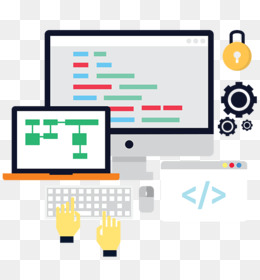

### Ejercicio 1- Tablas de multiplicar

Escribir una función que pida un número entero entre `1 y 10` y guarde en un fichero con el nombre `tabla-n.txt` la tabla de multiplicar de ese número, donde n es el número introducido.

### Solución 1:

### Solución 2:

### Ejercicio 2 - Mostrando tablas de Multiplicar

Escribir una función que pida un número entero entre `1 y 10`, lea el fichero `tabla-n.txt` con la tabla de multiplicar de ese número, done n es el número introducido, y la muestre por pantalla. Si el fichero no existe debe mostrar un mensaje por pantalla informando de ello.

### Solución:

### Ejercicio 3 - Linea M tabla.

Escribir una función que pida dos números `n` y `m` entre 1 y 10, lea el fichero `tabla-n.txt` con la tabla de multiplicar de ese número, y muestre por pantalla la línea `m` del fichero. Si el fichero no existe debe mostrar un mensaje por pantalla informando de ello.

### Solución:

### Ejercicio 4 Contar Palabras fichero internet.

Escribir una función que acceda a un fichero de internet mediante su url y muestre por pantalla el número de palabras que contiene. Si el fichero no existe, deberá mostrar un mensaje informativo.

Nota: Podéis usar la página https://www.gutenberg.org/ donde hay libros en formato de texto plano.

### Solución:

In [ ]:
# Ejercicio 4 Contar Palabras fichero internet.
# Escribir una función que acceda a un fichero de internet mediante su url y muestre 
# por pantalla el número de palabras que contiene. Si el fichero no existe, deberá 
# mostrar un mensaje informativo.
# 
# Nota: Podéis usar la página https://www.gutenberg.org/ donde hay libros en formato 
# de texto plano.

# Importaciones
from urllib import request
from urllib.error import URLError

# Funcion para contar las palabras de un libro URL
def contarPalabrasLibroURL(url):
    # Accedemos al fichero de internet mediante su URL
    # Si el fichero no existe se muestra un mensaje de error.
    try:
        with request.urlopen(url) as f:
            # Decodificamos el contenido a UTF-8 y lo separamos en palabras
            contenido = f.read().decode('utf-8')
            palabras = contenido.split()
            # Mostramos el numero de palabras del fichero URL
            print(f"El fichero contiene {len(palabras):,} palabras.")
    except URLError:
        print('¡La url ' + url + ' no existe!')

contarPalabrasLibroURL('https://www.gutenberg.org/cache/epub/1619/pg1619.txt')

### Ejercicio 5 - Personas

En este ejercicio deberás crear un script llamado personas.py que lea los datos de un fichero de texto, que transforme cada fila en un diccionario y lo añada a una lista llamada personas. Luego recorre las personas de la lista y para cada una muestra de forma amigable todos sus campos.

El fichero de texto se denominará **personas.txt** y tendrá el siguiente contenido en texto plano (créalo previamente):

1;Carlos;Pérez;05/01/1989

2;Manuel;Heredia;26/12/1973

3;Rosa;Campos;12/06/1961

4;David;García;25/07/2006

### Solución:

### Ejercicio 6 - Contador

En este ejercicio deberás crear una función que realice varias tareas sobre un fichero llamado **contador.txt** que almacenará un contador de visitas (será un número):

Nuestro script trabajará sobre el fichero contador.txt. 

* Si el fichero no existe o está vacío lo crearemos con el número 0. 

* Si existe simplemente leeremos el valor del contador.

**Luego a partir de un argumento:**

1. Si se envía el argumento inc, se incrementará el contador en uno y se mostrará por pantalla.

2. Si se envía el argumento dec, se decrementará el contador en uno y se mostrará por pantalla.

3. Si no se envía ningún argumento (o algo que no sea inc o dec), se mostrará el valor del contador por pantalla.

Finalmente guardará de nuevo el valor del contador de nuevo en el fichero.

Utiliza excepciones si crees que es necesario, puedes mostrar el mensaje: Error: Fichero corrupto.

### Solución:

In [ ]:
# Fichero contador
ficheroContador = 'contador.txt'

# Funcion para leer el valor de contador del fichero
def leerFicheroContador():
    try:
        # Abrimos el fichero en modo lectura
        with open(ficheroContador, 'r') as fichero:
            # Obtenemos el valor del contador eliminando espacios en blanco
            # para evitar errores al convertir a tipo entero
            contenido = fichero.read().strip()
            # Si el fichero esta vacio inicamos el contador a 0
            if not contenido:
                return 0
            # Sino devolvemos el valor del contador converitido a entero
            else:
                return int(contenido)
    # Si el fichero no existe devolvemos contador a 0
    except FileNotFoundError:
        return 0
    # Excepcion para manejar errores
    except ValueError:
        raise ValueError('Error. Fichero corrupto')

# Funcion para guardar el valor del contador en el fichero
def guardarValorContador(valor):
    # Abrimos el fichero en modo escritura
    with open(ficheroContador, 'w') as fichero:
        # Escribimos el valor de contador en el fichero
        fichero.write(str(valor))

# Funcion para ejecutar el contador
def contador(argumento):
    try:
        # Obtenemos el valor del contador del fichero
        valor = leerFicheroContador()
        # Si tiene arguemnto ejectuamos la accion correspondiente
        if argumento == 'inc':
            valor += 1
            print(f'Contador incrementado: {valor}')
        elif argumento == 'dec':
            valor -= 1
            print(f'Contador decrementado: {valor}')
        # Sino devolvemos el valor del contador por pantalla
        else:
            print(f'Valor del contador: {valor}')
        # Guardamos el valor actualizado del contador nuevo en el fichero
        guardarValorContador(valor)
    except ValueError as error:
        print(f"Error: {error}")

contador('')
contador('inc')
contador('dec')
contador('dec')
contador('')

### Ejercicio 7. Cotizaciones IBEX

El fichero **[cotizacion.csv](../7Trabajando_Con_Ficheros/cotizacion.csv)** contiene las cotizaciones de las empresas del IBEX35 con las siguientes columnas: 

* Nombre (nombre de la empresa)

* Final (precio de la acción al cierre de bolsa)

* Máximo (precio máximo de la acción durante la jornada)

* Mínimo (precio mínimo de la acción durante la jornada)

* Volumen (Volumen al cierre de bolsa)

* Efectivo (capitalización al cierre en miles de euros).


1. Construir una función reciba el fichero de cotizaciones y devuelva un diccionario con los datos del fichero por columnas. Con el siguiente formato:

cotizaciones = {

                Nombre   : ['ACCIONA', 'ACERINOX', 'ACS', 'AENA', 'AMADEUS', 'ARCELORMIT ...]
                
                Final    : [95.95, 86.68, 37.28, 167.1 ...]
                
                Máximo   : [96.75, 86.72, 37.22 ...]
                
                Mínimo   : [...]
                
                Volumen  : [...]
                
                Efectivo : [...]
                
               }

**Nota:**
Ten en cuenta que quizás los números no vengan con el formato adecuado y haya que realizar algunas transformaciones. Abre el fichero csv y analiza como están viniendo los valores númericos.              

2. Construir una función que reciba el diccionario devuelto por la función anterior y cree un fichero en formato csv con el mínimo, el máximo y la media de dada columna.

### Solución:

### Ejercicio 8.

El fichero **[calificaciones.csv](../7Trabajando_Con_Ficheros/calificaciones.csv)** contiene las calificaciones de un curso. Durante el curso se realizaron dos exámenes parciales de teoría y un examen de prácticas. Los alumnos que tuvieron menos de 4 en alguno de estos exámenes pudieron repetirlo al final del curso (convocatoria ordinaria). Escribir un programa que contenga las siguientes funciones:

1. Una función que reciba el fichero de calificaciones y devuelva una lista de diccionarios, donde cada diccionario contiene la información de los exámenes y la asistencia de un alumno. La lista tiene que estar ordenada por apellidos.


2. Una función que reciba una lista de diccionarios como la que devuelve la función anterior y añada a cada diccionario un nuevo par con la nota final del curso. El peso de cada parcial de teoría en la nota final es de un 30% mientras que el peso del examen de prácticas es de un 40%.


3. Una función que reciba una lista de diccionarios como la que devuelve la función anterior y devuelva dos listas, una con los alumnos aprobados y otra con los alumnos suspensos. Para aprobar el curso, la asistencia tiene que ser mayor o igual que el 75%, la nota de los exámenes parciales y de prácticas mayor o igual que 4 y la nota final mayor o igual que 5.


### Solución:

In [ ]:
# Fichero de calificaciones
ficheroCalificaciones = 'calificaciones.csv'

# Metodo para convertir el sting a float
def obtenerNota(valor):
    # Si el valor es None o una cadena vacia devolvemos None
    if valor is None or valor.strip() == '':
        return None
    # Si no lo convertimos a float cambiando la coma por el punto decimal
    else:
        return float(valor.strip().replace(',', '.'))

# Metodo para leer el fichero de calificaciones
def leerFicheroCalificaciones(ficheroCalificaciones):
    # Lista de alumnos
    calificacionesAlumnos = []
    # Abrimos el fichero en modo lectura
    with open(ficheroCalificaciones, encoding="utf-8") as fichero:
        # Obtenemos las lienas del fichero
        lineas = fichero.readlines()
    # Ontenemos la cabecera del fichero separando los valores por ;
    cabecera = []
    for columna in lineas[0].split(';'):
        cabecera.append(columna.strip())
    # Recorremos las lineas del fichero a partir de la cabecera
    for linea in lineas[1:]:
        # Si la linea esta vacia pasamos a la siguiente
        if not linea.strip():
            continue
        # Si la linea no esta vacia separamos los valores por ;
        else:
            valores = linea.strip().split(';')
            # Creamos un diccionario con la cabecera y el valor de la columna
            fila = dict(zip(cabecera, valores))
            # Creamos un diccionario con los datos del alumno
            alumno = {
                'Apellidos':          fila['Apellidos'],
                'Nombre':             fila['Nombre'],
                'Asistencia':         int(fila['Asistencia'].replace('%', '')), # Convertimos el porcentaje a entero
                'Parcial1':           obtenerNota(fila['Parcial1']),
                'Parcial2':           obtenerNota(fila['Parcial2']),
                'Ordinario1':         obtenerNota(fila['Ordinario1']),
                'Ordinario2':         obtenerNota(fila['Ordinario2']),
                'Practicas':          obtenerNota(fila['Practicas']),
                'OrdinarioPracticas': obtenerNota(fila['OrdinarioPracticas']),
            }
            # Los añadimos a la lista de calificaciones de los alumnos
            calificacionesAlumnos.append(alumno)
    # Ordenamos la lista por apellidos
    calificacionesAlumnos.sort(key=lambda a: a["Apellidos"])
    return calificacionesAlumnos

# Metodo para calcular la nota final de cada alumno
def obtenerNotaFinal(alumnos):
    # Recorremos la lista de alumnos
    for alumno in alumnos:
        parcial1 = None
        parcial2 = None
        practicas = None
        # Obtenemos las notas de los examenes de cada alumno
        if alumno['Ordinario1'] is not None:
            parcial1 = alumno['Ordinario1']
        else:
            parcial1 = alumno['Parcial1']
        if alumno['Ordinario2'] is not None:
            parcial2 = alumno['Ordinario2']
        else:
            parcial2 = alumno['Parcial2']
        if alumno['OrdinarioPracticas'] is not None:
            practicas = alumno['OrdinarioPracticas']
        else:
            practicas = alumno['Practicas']
        # Si alguna de las notas es None, la nota final es None
        if parcial1 is None or parcial2 is None or practicas is None:
            alumno['NotaFinal'] = None
        # Sino calculamos la nota final redondendo a 2 decimales
        else:
            alumno['NotaFinal'] = round(parcial1 * 0.30 + parcial2 * 0.30 + practicas * 0.40, 2)
    return alumnos

# Metodo para clasificar los alumnos en aprobados y suspensos
def clasificacionAlumnos(alumnos):
    aprobados = []
    suspensos = []
    for alumno in alumnos:
        parcial1 = None
        parcial2 = None
        practicas = None
        notaFinal = None
        # Obtenemos las notas de los examenes de cada alumno
        if alumno['Ordinario1'] is not None:
            parcial1 = alumno['Ordinario1']
        else:
            parcial1 = alumno['Parcial1']
        if alumno['Ordinario2'] is not None:
            parcial2 = alumno['Ordinario2']
        else:
            parcial2 = alumno['Parcial2']
        if alumno['OrdinarioPracticas'] is not None:
            practicas = alumno['OrdinarioPracticas']
        else:
            practicas = alumno['Practicas']
        notaFinal = alumno['NotaFinal']
        # Comprobamos que alumno cumpla las condiciones para aprobar o no
        if (notaFinal is not None and notaFinal >= 5 and alumno['Asistencia'] >= 75 and parcial1 is not None and parcial1 >= 4 and parcial2 is not None and parcial2 >= 4 and practicas is not None and practicas >= 4):
            aprobados.append(alumno)
        else:
            suspensos.append(alumno)
    # Mostramos los resultados
    print(f'Alumnos aprobados = {len(aprobados)}')
    for alumno in aprobados:
        print(f'- {alumno["Apellidos"]}, {alumno["Nombre"]}: {alumno["NotaFinal"]}')
    print(f'Alumnos suspensos = {len(suspensos)}')
    for alumno in suspensos:
        print(f'- {alumno["Apellidos"]}, {alumno["Nombre"]}: {alumno["NotaFinal"]}')

alumnos = leerFicheroCalificaciones(ficheroCalificaciones)
alumnos = obtenerNotaFinal(alumnos)
clasificacionAlumnos(alumnos)


___
### Ejercicio 9 - Anagramas.

Crea una serie de funciones para recibir un fichero de palabras (palabras.txt) y devolver en un fichero denominado "lista_anagramas.txt" todos los anagramas de cada una de las palabras. 

**La estructra de los ficheros será la siguiente:**

* **palabras.txt**
    
    * barca
    * cordón
    * usadme
    * pasiva
    * comas
    * trapean
    * grite
    
* **lista_anagramas.txt**

    barca : [braca, cabra, carba]
    
    cordón : [cóndor]
    
    usadme : [mudase, medusa]
    
    ...
    

**¿Qué es un anagrama?**

* Un anagrama es una palabra que resulta de la transposición de todas las letras de otra palabra. Dicho de otra forma, una palabra es anagrama de otra si las dos tienen las mismas letras, con el mismo número de apariciones, pero en un orden diferente.

Por tanto para resolver este ejercicio, **necesitaremos crear todas las combinaciones (permutaciones) posibles de letras de cada palabra y comprobar si tienen sentido.**

Para comprobar el sentido de las palabras generadas, tenemos un diccionario con todas las palabras en castellano. Para cada permutación generada, comprobamos si existe en el diccionario. En caso de existir, la almacenamos en el diccionario
final de soluciones.

Los anagramas resultantes, no serán ni la palabra original, y deberán ser palabras del castellano.


**Notas:** 

1. Se facilita el fichero **[diccionario_castellano.txt](../7Trabajando_Con_Ficheros/diccionario_castellano.txt)** con todas las palabras del castellano.


### Solución:

In [ ]:
# Ficheros
ficheroEntrada     = 'palabras.txt'
ficheroDiccionario = 'diccionario_castellano.txt'
ficheroSalida      = 'lista_anagramas.txt'

# Metodo para obtener las palabras sin acentos y ordenadas alfabeticamente
def obtenerClave(palabra):
    # Pasamos a minúsculas y sustituimos cada vocal 'especial' por un valor normalizado
    palabra = palabra.lower()
    vocales = [('á', 'a'), ('é', 'e'), ('í', 'i'), ('ó', 'o'), ('ú', 'u'), ('ü', 'u'), ('ñ', 'n')]
    for caracterEspecial, normalizado in vocales:
        palabra = palabra.replace(caracterEspecial, normalizado)
    letras = []
    # Añadimos cada letra a la lista y la ordenamos alfabeticamente
    for letra in palabra:
        letras.append(letra)
    letras.sort()
    # Devolvemos una tupla que sera la clave del diccionario
    return tuple(letras)

# Metodo para cargar el diccionario de palabras agrupadas
def cargarDiccionario(ficheroDiccionario):
    diccionario = {}
    with open(ficheroDiccionario, encoding='utf-8') as fichero:
        lineas = fichero.readlines()
    for linea in lineas:
        palabra = linea.strip()
        # Ignoramos lineas vacias o compuestas
        if not palabra or ' ' in palabra:
            continue
        clave = obtenerClave(palabra)
        # Si la firma no existe la creamos con una lista vacia
        if clave not in diccionario:
            diccionario[clave] = []
        # Añadimos la palabra si no esta en la lista
        if palabra.lower() not in diccionario[clave]:
            diccionario[clave].append(palabra.lower())
    return diccionario

# Metodo para leer las palabras del fichero de entrada
def leerPalabras(ficheroEntrada):
    palabras = []
    with open(ficheroEntrada, encoding='utf-8') as fichero:
        lineas = fichero.readlines()
    for linea in lineas:
        if linea.strip():
            palabras.append(linea.strip())
    return palabras

# Metodo para encontrar los anagramas de cada palabra
def encontrarAnagramas(palabras, diccionarioPorClave):
    resultado = {}
    for palabra in palabras:
        clave = obtenerClave(palabra)
        # Obtenemos los candidatos con la misma clave
        if clave in diccionarioPorClave:
            candidatos = diccionarioPorClave[clave]
        else:
            candidatos = []
        # Filtramos la palabra original y ordenamos los anagramas
        anagramas = []
        for candidato in candidatos:
            if candidato.lower() != palabra.lower():
                anagramas.append(candidato)
        anagramas.sort()
        resultado[palabra] = anagramas
    return resultado

# Metodo para guardar el resultado en el fichero de salida
def guardarAnagramas(ficheroSalida, resultado):
    with open(ficheroSalida, 'w', encoding='utf-8') as fichero:
        for palabra, anagramas in resultado.items():
            fichero.write(f'{palabra} : {anagramas}\n')

diccionario = cargarDiccionario(ficheroDiccionario)
palabras = leerPalabras(ficheroEntrada)
resultado = encontrarAnagramas(palabras, diccionario)
guardarAnagramas(ficheroSalida, resultado)